# EVALUACIÓN FINAL: IMPACTO DEL CAMBIO CLIMÁTICO EN LA PRODUCCIÓN AGRÍCOLA

Eres un analista de datos en un centro de investigación sobre cambio climático y seguridad alimentaria. Te han encomendado evaluar cómo **factores climáticos** afectan la **producción agrícola** en distintos países, aplicando modelos de **aprendizaje supervisado** para predecir producción y **clasificar países** según su vulnerabilidad.


## Objetivos de la evaluación
- Aplicar técnicas de **regresión** para predecir la producción agrícola en función de variables climáticas.  
- Utilizar algoritmos de **clasificación** para categorizar los países según el impacto del cambio climático.  
- Evaluar el desempeño de los modelos mediante **métricas adecuadas**.  
- Aplicar **preprocesamiento de datos** para mejorar la calidad del análisis.  
- **Optimizar** los modelos a través de ajuste de hiperparámetros.


## 1. Carga y exploración de datos (1 punto)
- Carga el dataset (temperatura media, cambio en precipitaciones, frecuencia de sequías, producción agrícola, etc.).  
- Analiza la **distribución** de las variables y detecta **valores atípicos** o **tendencias**.


In [67]:
# Librerias 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
from scipy.stats import shapiro
import statsmodels.api as sm
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline   
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split



In [31]:
# Funciones

def tabla(dfx, fmt='fancy_grid', decimals=2, title=None):
    """
    Muestra un DataFrame o Series en formato tabulado con título opcional.
    
    Parámetros:
    dfx : DataFrame o Series
    fmt : str, formato de tabulate (default: 'fancy_grid')
    decimals : int, número de decimales (default: 2)
    title : str, título de la tabla (default: None)
    """
    # Si es Series → convertir a DataFrame
    if isinstance(dfx, pd.Series):
        dfx = dfx.to_frame(name="Valor")

    # Redondear si son datos numéricos
    try:
        dfx = dfx.round(decimals)
    except:
        pass  # ignora si no aplica

    # Imprimir título si existe
    if title:
        print(f"\n {title}\n" + "-" * (len(title) + 2))

    print(tabulate(dfx, headers="keys", tablefmt=fmt))

def make_viridis_palette(k=12, span=(0.15, 0.95)):
    cmap = plt.colormaps.get_cmap('viridis')   # ✅ forma nueva y segura
    return cmap(np.linspace(span[0], span[1], k))


VIRIDIS = make_viridis_palette(k=12)

def boxplot_viridis(
    df, col, n=0, *,
    whis=(5, 95),          # bigotes por percentiles (más robusto que 1.5*IQR si hay colas largas)
    showfliers=False,      # oculta outliers por defecto (puedes poner True)
    log=False,             # escala log opcional
    title_prefix="Distribución de"
):
    """
    Boxplot horizontal con Viridis, configurable y limpio.
    - df: DataFrame
    - col: nombre de la columna numérica a graficar
    - n: índice para elegir color en la paleta VIRIDIS
    - whis: "1.5" para usar el 1.5*IQR, o "(5,95)" para más robustez 
    """
    serie = df[col].dropna().values
    c = VIRIDIS[n % len(VIRIDIS)]  # color viridis ciclado
    label = col.replace("_", " ")

    plt.figure(figsize=(8, 5))
    plt.boxplot(
        serie,
        vert=False,
        patch_artist=True,
        whis=whis,
        #showfliers=showfliers,
        boxprops=dict(facecolor=c, edgecolor=c, linewidth=1.6, alpha=0.95),
        medianprops=dict(color="red", linewidth=2.2),
        whiskerprops=dict(color=c, linewidth=1.6),
        capprops=dict(color=c, linewidth=1.6),
        flierprops=dict(marker="o", markerfacecolor="orange", markeredgecolor="black",
                        markersize=6, alpha=0.6, linestyle="none")
    )

    if log:
        plt.xscale("log")
        plt.xlabel(f"{label} (escala log)")
    else:
        plt.xlabel(label)

    plt.title(f"{title_prefix} {label}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

def plot_hist_kde(df, col, ax=None, *, bins='sturges', n=0, title_prefix="Distribución"):
    """
    Histograma + KDE para la columna 'col'.
    """
    serie = df[col].dropna()
    c = VIRIDIS[n % len(VIRIDIS)]
    if ax is None:
        fig, ax = plt.subplots(figsize=(5,4))

    sns.histplot(serie, kde=True, bins=bins, ax=ax, color=c)
    ax.set_title(f"{title_prefix}: {col.replace('_',' ')}", weight="bold", fontsize=12)
    ax.set_xlabel("")
    ax.grid(axis="y", alpha=0.2)
    return ax

def detectar_outliers_iqr(
    df: pd.DataFrame,
    columna: str,
    n,
    graficar: bool = True,
    inplace: bool = False
):
    """
    Detecta y filtra outliers (IQR). Si inplace=True, modifica df en sitio.
    
    Returns:
        outliers (pd.DataFrame): Filas detectadas como outliers.
        df_filtrado (pd.DataFrame): DataFrame sin outliers (o None si inplace=True).
        limites (dict): Q1, Q3, IQR, límites.
    """
        # 1) (Opcional) Gráfico
    if graficar:
        boxplot_viridis(df, columna, n=n, whis=1.5)

    # 2) Cuartiles e IQR
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1

    # 3) Límites de Tukey
    li = Q1 - 1.5 * IQR
    ls = Q3 + 1.5 * IQR

    # 4) Máscara de outliers (NaN no cuenta como outlier)
    mask_out = (df[columna] < li) | (df[columna] > ls)

    # 5) Subsets
    outliers = df.loc[mask_out].copy()
    df_filtrado = df.loc[~mask_out].copy()

    # 6) Métricas y salida formateada
    total_validos = df[columna].notna().sum()
    num_out = int(mask_out.sum())
    pct_out = (num_out / total_validos * 100.0) if total_validos > 0 else 0.0

    limites = {"Q1": Q1, "Q3": Q3, "IQR": IQR,
               "limite_inferior": li, "limite_superior": ls}    
    
    # 7) Impresión de resultados
    print(f"Outliers detectados en {columna}: {num_out} ({pct_out:.2f}%)")
    print("Límites:")
    for k, v in limites.items():
        print(f"  {k}: {v:,.2f}")
    print("Tamaño sin outliers:", df_filtrado.shape)

    # 8) In-place o retorno
    if inplace:
        # Modifica el df original en el caller usando índices (sin reasignar la variable local)
        df.drop(df.index[mask_out], inplace=True)
        return outliers, None, limites
    else:
        return outliers, df_filtrado, limites
    

# ========= Utilidad: Shapiro con manejo de errores =========
def shapiro_safe(x):
    """
    Ejecuta Shapiro-Wilk ignorando NaN y maneja casos con pocos datos o constantes.
    Retorna (stat, pvalue, msg).
    """
    x = pd.Series(x).dropna().values
    if len(x) < 3:
        return np.nan, np.nan, "muestra insuficiente (<3)"
    # Shapiro requiere que no sean todos iguales
    if np.allclose(x, x[0]):
        return np.nan, np.nan, "valores constantes"
    try:
        stat, pval = shapiro(x)
        return stat, pval, None
    except Exception as e:
        return np.nan, np.nan, f"error: {e}"


# ========= 1) HISTOGRAMA + KDE =========
def plot_hist_kde(df, col, ax=None, *, bins='sturges', n=0, title_prefix="Distribución"):
    """
    Histograma + KDE para la columna 'col'.
    """
    serie = df[col].dropna()
    c = VIRIDIS[n % len(VIRIDIS)]
    if ax is None:
        fig, ax = plt.subplots(figsize=(5,4))

    sns.histplot(serie, kde=True, bins=bins, ax=ax, color=c)
    ax.set_title(f"{title_prefix}: {col.replace('_',' ')}", weight="bold", fontsize=12)
    ax.set_xlabel("")

    return ax


# ========= 2) QQ-PLOT (con p-value de Shapiro opcional) =========
def plot_qq(df, col, ax=None, *, n=0, show_pvalue=True, alpha=0.05):
    """
    QQ-plot contra normal. Si show_pvalue=True, calcula Shapiro y lo muestra en el título.
    """
    serie = df[col].dropna()
    c = VIRIDIS[n % len(VIRIDIS)]
    if ax is None:
        fig, ax = plt.subplots(figsize=(5,4))

    # statsmodels dibuja sus propios puntos; ajustamos línea 45
    sm.qqplot(serie, ax=ax, fit=True, line="45", markerfacecolor=c, markeredgecolor="black", alpha=0.7)
    ax.set_xlabel("Cuantiles teóricos")
    ax.set_ylabel("Cuantiles muestrales")

    title = col.replace("_"," ")
    if show_pvalue:
        _, pval, err = shapiro_safe(serie)
        if err is None and not np.isnan(pval):
            normal_msg = "no normal" if pval < alpha else "no se descarta normalidad"
            title = f"{title}\nShapiro p={pval:.3f} ({normal_msg})"
        else:
            title = f"{title}\nShapiro: {err}"
    ax.set_title(title, weight="bold", fontsize=12)

    return ax


# ========= 3) BOXPLOT VIRIDIS (horizontal) =========
def boxplot_viridis(
    df, col, ax=None, n=0, *,
    whis=(5, 95),
    showfliers=False,
    log=False,
    title_prefix="Distribución de"
):
    """
    Boxplot horizontal con Viridis.
    """
    serie = df[col].dropna().values
    c = VIRIDIS[n % len(VIRIDIS)]
    label = col.replace("_", " ")

    if ax is None:
        fig, ax = plt.subplots(figsize=(6,4))

    ax.boxplot(
        serie,
        vert=False,
        patch_artist=True,
        whis=whis,
        showfliers=showfliers,
        boxprops=dict(facecolor=c, edgecolor=c, linewidth=1.6, alpha=0.95),
        medianprops=dict(color="red", linewidth=2.2),
        whiskerprops=dict(color=c, linewidth=1.6),
        capprops=dict(color=c, linewidth=1.6),
        flierprops=dict(marker="o", markerfacecolor="orange", markeredgecolor="black",
                        markersize=6, alpha=0.6, linestyle="none")
    )

    if log:
        ax.set_xscale("log")
        ax.set_xlabel(f"{label} (escala log)")
    else:
        ax.set_xlabel(label)

    ax.set_yticks([])
    ax.set_title(f"{title_prefix} {label}", fontsize=12, weight="bold")
    return ax


# ========= 4) FUNCIÓN MAESTRA: los 3 gráficos en una sola imagen =========
def triple_plot(df, col, *, n=0, bins='sturges', alpha=0.05, whis=(5,95), showfliers=False, log=False):
    """
    Dibuja en una figura: Histograma+KDE | QQ-plot | Boxplot viridis.
    Reutiliza las funciones anteriores.
    """
    fig, axs = plt.subplots(1, 3, figsize=(15, 4))
    plot_hist_kde(df, col, ax=axs[0], bins=bins, n=n)
    plot_qq(df, col, ax=axs[1], n=n, show_pvalue=True, alpha=alpha)
    boxplot_viridis(df, col, ax=axs[2], n=n, whis=whis, showfliers=showfliers, log=log)

    fig.suptitle(f"Distribución de '{col}'", fontsize=14, weight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

In [32]:
# Carga de dataset

df=pd.read_csv("cambio_climatico_agricultura.csv",index_col="País")


 Primeras 5 filas
------------------
╒═══════════╤════════════════════════╤══════════════════╤══════════════════════╤════════════════════════╕
│ País      │   Temperatura_promedio │   Cambio_lluvias │   Frecuencia_sequías │   Producción_alimentos │
╞═══════════╪════════════════════════╪══════════════════╪══════════════════════╪════════════════════════╡
│ Alemania  │                   10.5 │               -5 │                    2 │                 950000 │
├───────────┼────────────────────────┼──────────────────┼──────────────────────┼────────────────────────┤
│ Argentina │                   17.8 │              -10 │                    5 │                 650000 │
├───────────┼────────────────────────┼──────────────────┼──────────────────────┼────────────────────────┤
│ Australia │                   22.3 │              -15 │                    8 │                 400000 │
├───────────┼────────────────────────┼──────────────────┼──────────────────────┼────────────────────────┤
│ Brasil

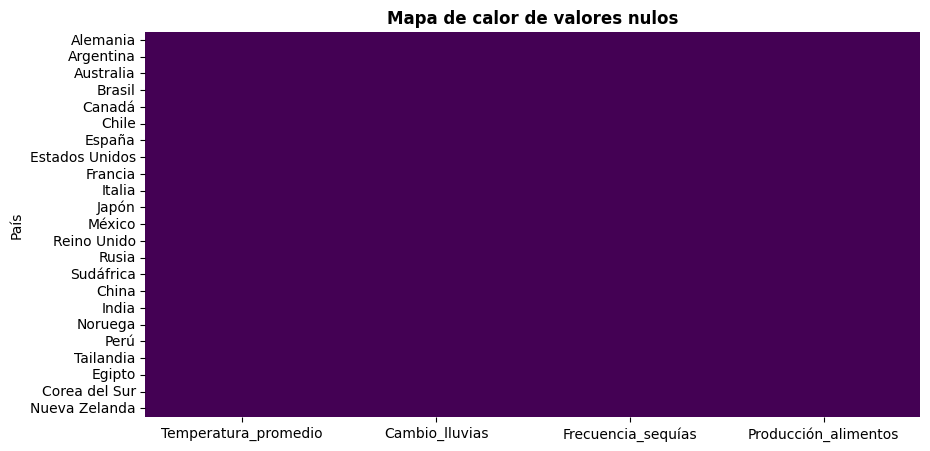

In [33]:
# Exploración inicial

tabla(df.head(5),title="Primeras 5 filas")

print(f"Información inicial del data set:")

df.columns= df.columns.str.replace(" ", "") # Cambio de nombres de columnas
tabla(df.info())

print("\n Dimensiones del DataFrame:", df.shape)

# Deteccion de duplicados
print(f'Número de duplicados: {df.duplicated().sum()}')

# Detección de valores nulos
tabla(df.isnull().sum(), title=" Valores nulos:")

tabla(df.describe(),title=" Estadísticas descriptivas:")

# Visualización nulos

plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=True,
            color=sns.color_palette("viridis")[3])
plt.title("Mapa de calor de valores nulos", fontsize=12, fontweight="bold")
plt.show()

In [34]:
df

,Temperatura_promedio,Cambio_lluvias,Frecuencia_sequías,Producción_alimentos
País,,,,
Alemania,10.5,-5,2,950000
Argentina,17.8,-10,5,650000
Australia,22.3,-15,8,400000
Brasil,25.1,-8,6,900000
Canadá,6.2,-2,1,850000
Chile,15.4,-12,7,500000
España,18.2,-9,6,600000
Estados Unidos,12.8,-4,3,1200000
Francia,11.5,-6,2,980000



 DataFrame numérica
--------------------
╒═══════════╤════════════════════════╤══════════════════╤══════════════════════╤════════════════════════╕
│ País      │   Temperatura_promedio │   Cambio_lluvias │   Frecuencia_sequías │   Producción_alimentos │
╞═══════════╪════════════════════════╪══════════════════╪══════════════════════╪════════════════════════╡
│ Alemania  │                   10.5 │               -5 │                    2 │                 950000 │
├───────────┼────────────────────────┼──────────────────┼──────────────────────┼────────────────────────┤
│ Argentina │                   17.8 │              -10 │                    5 │                 650000 │
├───────────┼────────────────────────┼──────────────────┼──────────────────────┼────────────────────────┤
│ Australia │                   22.3 │              -15 │                    8 │                 400000 │
├───────────┼────────────────────────┼──────────────────┼──────────────────────┼────────────────────────┤
│ Br

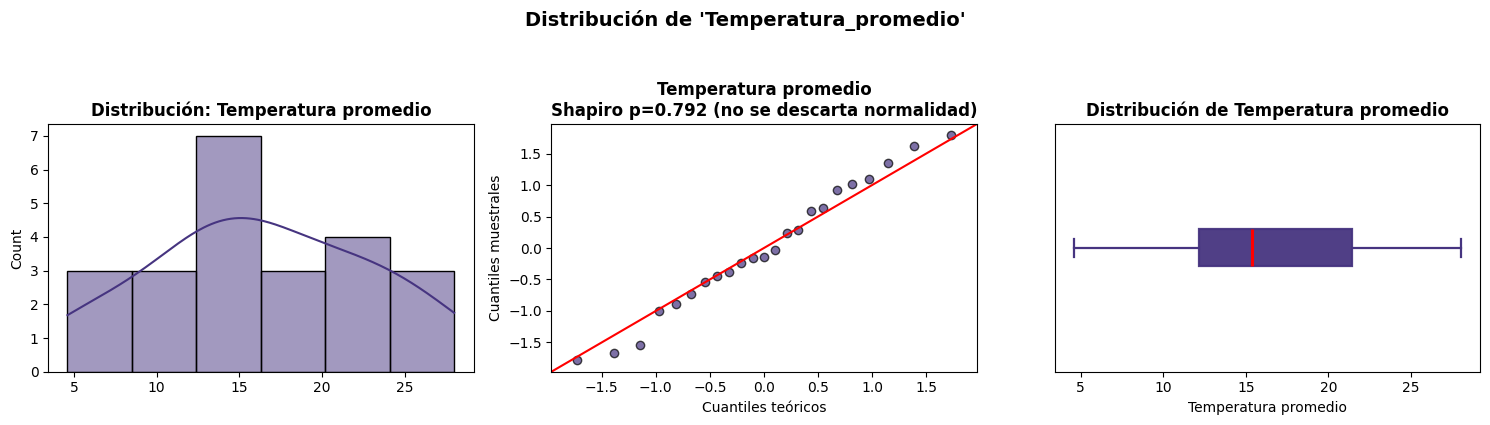

Outliers detectados en Cambio_lluvias: 0 (0.00%)
Límites:
  Q1: -11.00
  Q3: -4.50
  IQR: 6.50
  limite_inferior: -20.75
  limite_superior: 5.25
Tamaño sin outliers: (23, 4)


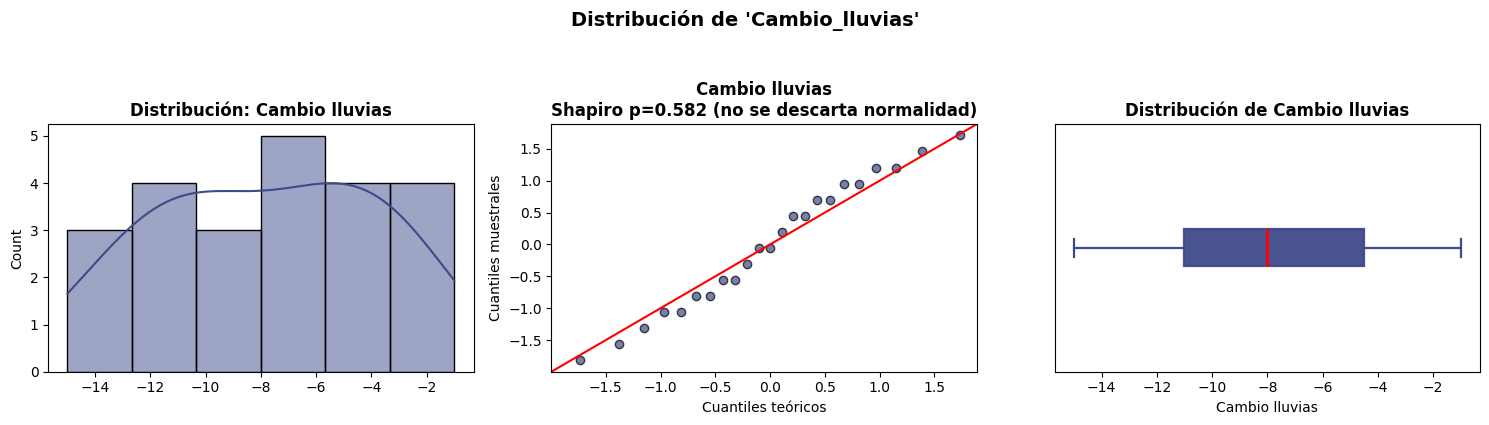

Outliers detectados en Frecuencia_sequías: 0 (0.00%)
Límites:
  Q1: 2.00
  Q3: 6.50
  IQR: 4.50
  limite_inferior: -4.75
  limite_superior: 13.25
Tamaño sin outliers: (23, 4)


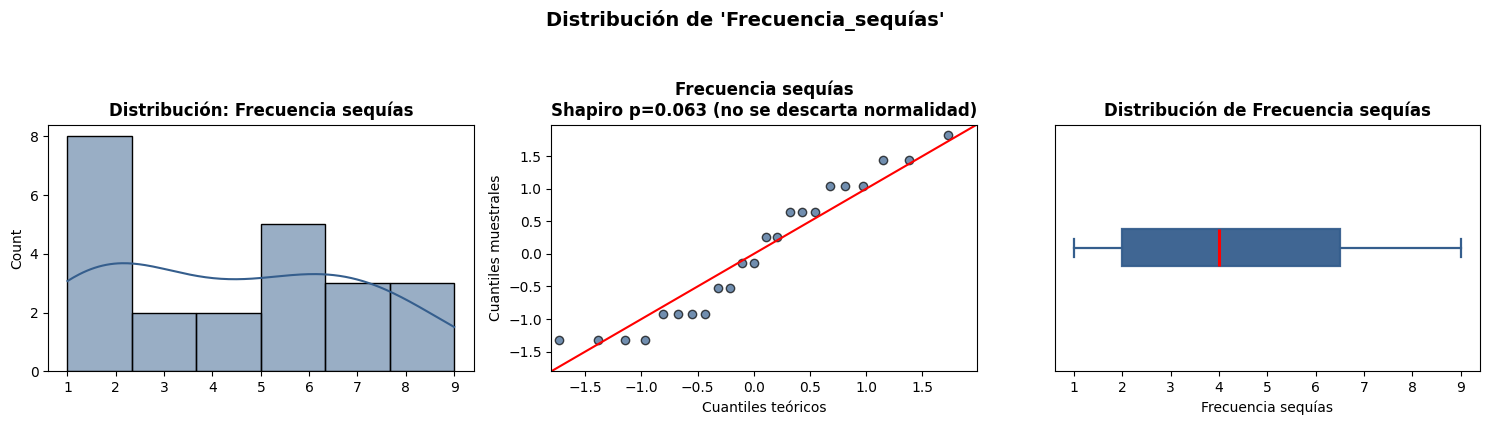

Outliers detectados en Producción_alimentos: 0 (0.00%)
Límites:
  Q1: 525,000.00
  Q3: 895,000.00
  IQR: 370,000.00
  limite_inferior: -30,000.00
  limite_superior: 1,450,000.00
Tamaño sin outliers: (23, 4)


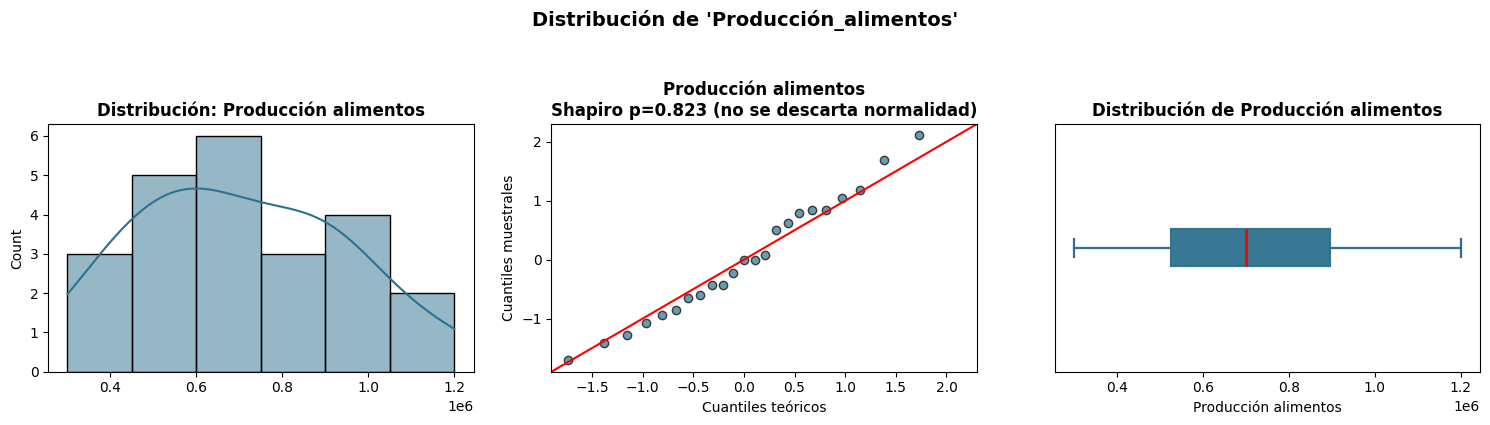

In [35]:
# Detección de valores atípicos
columnas_numericas = df.select_dtypes(include=["int64", "float64"]).columns
df_numerica=df[columnas_numericas]
tabla(df_numerica.head(5),title="DataFrame numérica")
n=0
for col in columnas_numericas:
    detectar_outliers_iqr(df,col,graficar=False,n=n)
    triple_plot(df, col, n=n, bins='sturges', alpha=0.05, whis=1.95, showfliers=False, log=False)
    n+=1

## 2. Preprocesamiento y escalamiento de datos (2 puntos)
- Aplica **normalización** o **estandarización** a variables numéricas.  
- Codifica correctamente variables **categóricas** si fuera necesario.  
- Divide los datos en **train/test (80%-20%)**.


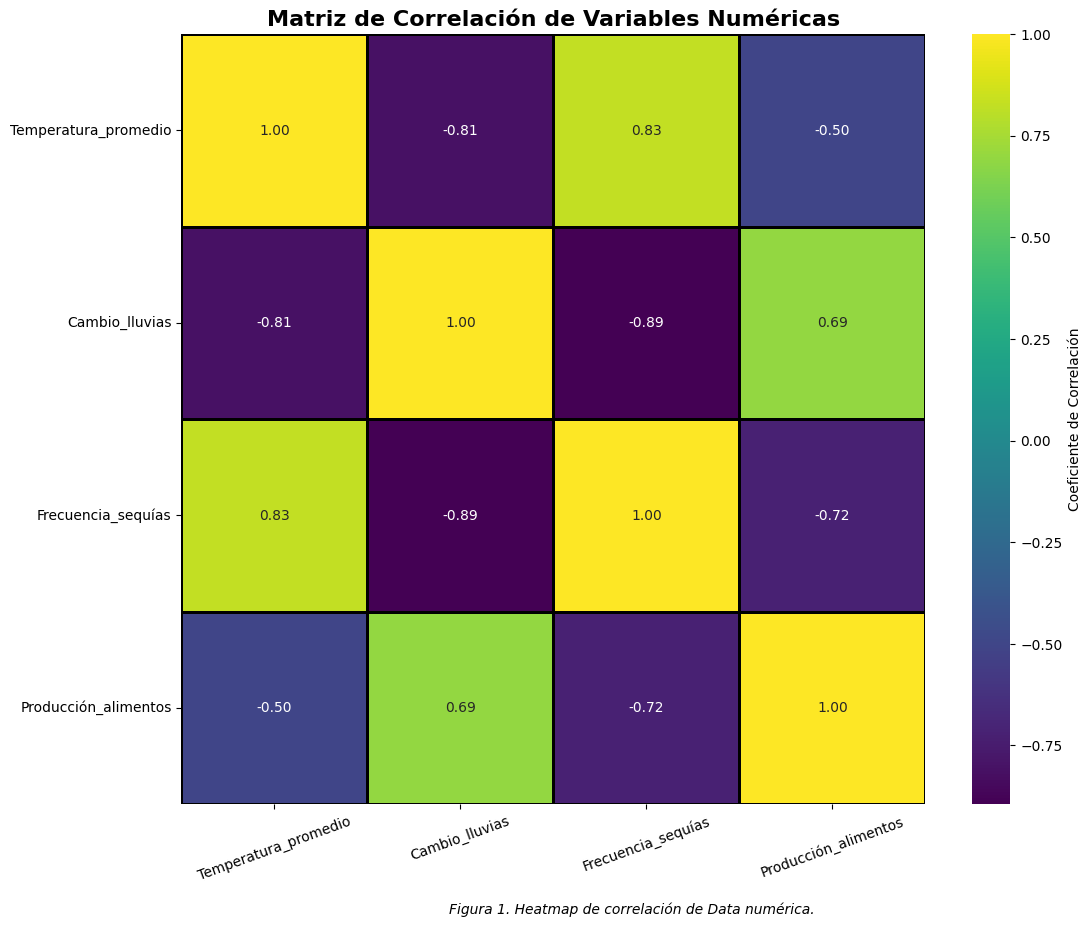

In [36]:
# Matriz de Correlación

plt.figure(figsize=(12, 10)) # Ajusta el tamaño del gráfico
sns.heatmap(df_numerica.corr(),
            annot=True,
            cmap='viridis', # Cambiamos el mapa de colores
            fmt=".2f",
            linewidths=1,   # Mayor grosor de líneas
            linecolor='black', # Color de las líneas
            cbar_kws={'label': 'Coeficiente de Correlación'}) # Etiqueta de la barra de color
plt.title('Matriz de Correlación de Variables Numéricas',
           fontsize=16,
           fontweight="bold") # Tamaño del título
plt.xticks(fontsize=10,rotation=20) # Tamaño de las etiquetas del eje X
plt.yticks(fontsize=10, rotation=0) # Tamaño de las etiquetas del eje Y y rotación
# 🔹 Agregar un caption debajo del gráfico
plt.figtext(0.5,0 , "Figura 1. Heatmap de correlación de Data numérica.", 
            wrap=True, ha="center", fontsize=10, style='italic')
plt.show()

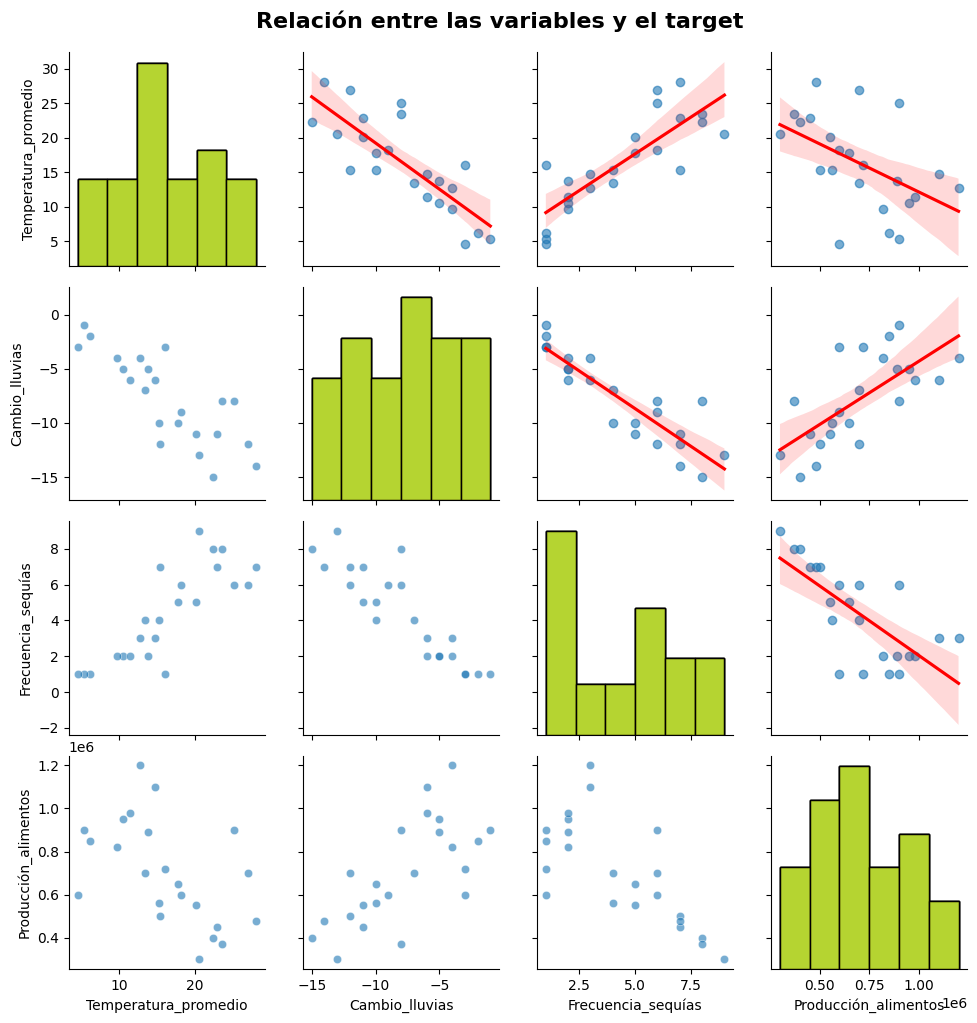

In [66]:
# Relación entre variables 

cols = df.columns
n_cols = len(cols)

# elegimos tantos colores como columnas haya
colors = make_viridis_palette(k=n_cols)

g = sns.PairGrid(df, diag_sharey=False)
g.map_upper(sns.regplot, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
g.map_lower(sns.scatterplot, alpha=0.6)
for i, col in enumerate(cols):
    g.map_diag(sns.histplot, color=colors[i])

plt.suptitle('Relación entre las variables y el target',
             weight='bold', fontsize=16, y=1.02)
plt.show()

In [ ]:
# Division del data frame 

X=df[['Temperatura_promedio','Cambio_lluvias','Frecuencia_sequías']]
y=df['Producción_alimentos']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalización de variables 

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)

# Unión de columnas escaladas al df 

X_scaled_all = scaler.transform(X)
scaled_cols = [f"{c}_minmax" for c in X.columns]
X_scaled_df = pd.DataFrame(X_scaled_all, columns=scaled_cols, index=X.index)

# Unimos al df original
df_escalada = df.join(X_scaled_df)

tabla(df_escalada.head(5),title="DataFrame escalado")



 DataFrame escalado
--------------------
╒═══════════╤════════════════════════╤══════════════════╤══════════════════════╤════════════════════════╤═══════════════════════════════╤═════════════════════════╤═════════════════════════════╕
│ País      │   Temperatura_promedio │   Cambio_lluvias │   Frecuencia_sequías │   Producción_alimentos │   Temperatura_promedio_minmax │   Cambio_lluvias_minmax │   Frecuencia_sequías_minmax │
╞═══════════╪════════════════════════╪══════════════════╪══════════════════════╪════════════════════════╪═══════════════════════════════╪═════════════════════════╪═════════════════════════════╡
│ Alemania  │                   10.5 │               -5 │                    2 │                 950000 │                          0.23 │                    0.71 │                        0.12 │
├───────────┼────────────────────────┼──────────────────┼──────────────────────┼────────────────────────┼───────────────────────────────┼─────────────────────────┼───────────────────


## 3. Modelos de aprendizaje supervisado (4 puntos)

**Regresión**  
- Entrena un modelo de **regresión lineal** para predecir la producción de alimentos.  
- Evalúa con **MAE, MSE y R²**.  
- Compara con otros modelos (árbol de decisión, random forest).


In [71]:

# Regresión lineal 

modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Predicción 
y_pred = modelo.predict(X_test)
r2=modelo.score(X_test, y_test)
mse=mean_squared_error( y_test, y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=mse**.5

# Tabla de resultados
valores = pd.DataFrame({
    "Métrica": ["R2", "MAE", "MSE", "RMSE"],
    "Lineal":   [r2,   mae,   mse,   rmse]
}).set_index("Métrica")

tabla(valores, decimals=3,title="Métricas de regresiones")



 Métricas de regresiones
-------------------------
╒═══════════╤══════════════════╕
│ Métrica   │           Lineal │
╞═══════════╪══════════════════╡
│ R2        │     -0.262       │
├───────────┼──────────────────┤
│ MAE       │ 178041           │
├───────────┼──────────────────┤
│ MSE       │      4.36982e+10 │
├───────────┼──────────────────┤
│ RMSE      │ 209041           │
╘═══════════╧══════════════════╛


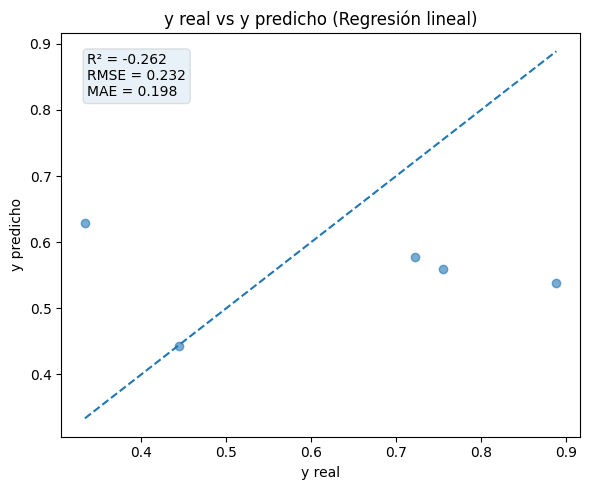

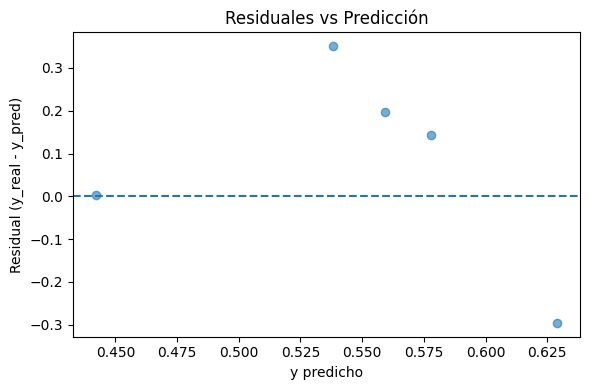

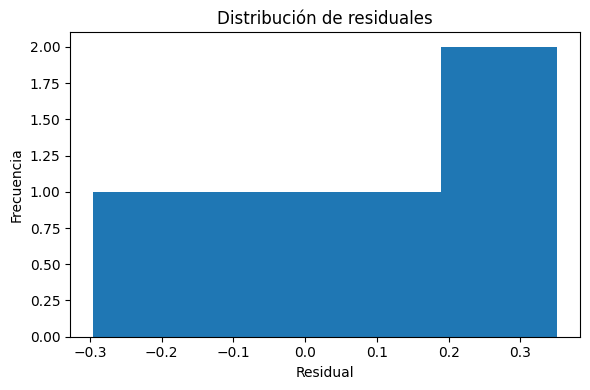

In [52]:
import matplotlib.pyplot as plt
import numpy as np

# Scatter y_test vs y_pred con línea identidad
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred, alpha=0.6)
lim_min = min(np.min(y_test), np.min(y_pred))
lim_max = max(np.max(y_test), np.max(y_pred))
plt.plot([lim_min, lim_max], [lim_min, lim_max], linestyle="--")  # línea y=x

plt.title("y real vs y predicho (Regresión lineal)")
plt.xlabel("y real")
plt.ylabel("y predicho")

# anotamos métricas
txt = f"R² = {r2:.3f}\nRMSE = {rmse:.3f}\nMAE = {mae:.3f}"
plt.gca().text(0.05, 0.95, txt, transform=plt.gca().transAxes,
               va="top", ha="left", bbox=dict(boxstyle="round", alpha=0.1))
plt.tight_layout()
plt.show()
resid = y_test - y_pred

# residuales vs predicción
plt.figure(figsize=(6, 4))
plt.scatter(y_pred, resid, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.title("Residuales vs Predicción")
plt.xlabel("y predicho")
plt.ylabel("Residual (y_real - y_pred)")
plt.tight_layout()
plt.show()

# histograma de residuales
plt.figure(figsize=(6, 4))
plt.hist(resid, bins="sturges")
plt.title("Distribución de residuales")
plt.xlabel("Residual")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()


**Clasificación**  
- Crea una variable categórica con impacto climático: **Bajo / Medio / Alto**.  
- Entrena modelos de **KNN, Árbol de Decisión y SVM**.  
- Evalúa con **matriz de confusión, precisión, sensibilidad y ROC-AUC**.


## 4. Optimización de modelos (2 puntos)
- Ajusta **hiperparámetros** con **validación cruzada** y **búsqueda en grilla**.  
- Aplica **regularización** y analiza su impacto.


## 5. Análisis de resultados y conclusiones (1 punto)
- Compara los modelos y justifica el mejor para **predicción** y **clasificación**.  
- Relaciona hallazgos con **seguridad alimentaria global**.


## INSTRUCCIONES ADICIONALES
- **Puntos totales = 10**.  
- Descarga el dataset proporcionado.  
- Comprime el proyecto (`.zip` o `.rar`) e incluye:  
  - Código fuente y análisis.  
  - Reflexión final sobre el impacto del cambio climático en la producción agrícola.  
- Sube el archivo a la plataforma.
